In [1]:
print("Student Performance Prediction")

Student Performance Prediction


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("../data/StudentsPerformance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
df.shape

(1000, 8)

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [17]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [19]:
X = df.drop("math score", axis=1)

In [21]:
y = df["math score"]

In [23]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [25]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [27]:
X = df.drop("math score", axis=1)
y = df["math score"]

X.head()
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [29]:
X.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
reading score                   int64
writing score                   int64
dtype: object

In [31]:
X = pd.get_dummies(X, drop_first=True)

In [33]:
X.head()

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [35]:
X.shape

(1000, 14)

In [37]:
X.dtypes

reading score                                    int64
writing score                                    int64
gender_male                                       bool
race/ethnicity_group B                            bool
race/ethnicity_group C                            bool
race/ethnicity_group D                            bool
race/ethnicity_group E                            bool
parental level of education_bachelor's degree     bool
parental level of education_high school           bool
parental level of education_master's degree       bool
parental level of education_some college          bool
parental level of education_some high school      bool
lunch_standard                                    bool
test preparation course_none                      bool
dtype: object

In [39]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
X.head()
X.shape

(1000, 14)

In [43]:
X.shape

(1000, 14)

In [45]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 14)
(200, 14)
(800,)
(200,)


In [53]:
from sklearn.linear_model import LinearRegression

In [55]:
model = LinearRegression()

In [57]:
model.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred = model.predict(X_test)

In [61]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,91,76.387970
1,53,58.885970
2,80,76.990265
3,74,76.851804
4,84,87.627378
5,81,79.014024
6,69,64.654609
7,54,53.007919
8,87,74.184710
9,51,49.213538


In [63]:
from sklearn.metrics import mean_absolute_error

In [65]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4.21476314247485


In [67]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,91,76.387970
1,53,58.885970
2,80,76.990265
3,74,76.851804
4,84,87.627378
5,81,79.014024
6,69,64.654609
7,54,53.007919
8,87,74.184710
9,51,49.213538


In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4.21476314247485


In [71]:
from sklearn.metrics import r2_score

In [73]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8804332983749565


In [75]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8804332983749565


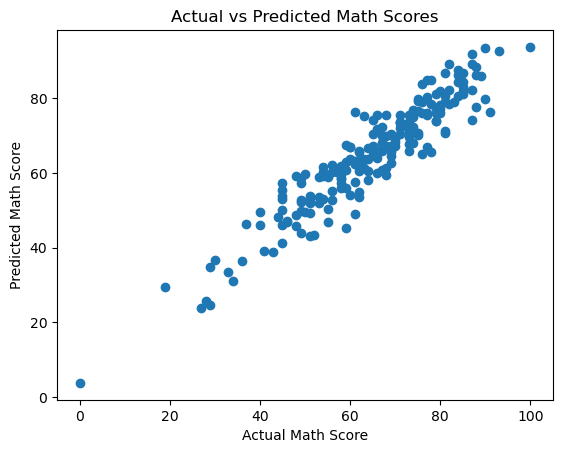

In [77]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")

plt.show()


In [79]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,gender_male,13.064884
6,race/ethnicity_group E,4.892649
12,lunch_standard,3.510075
13,test preparation course_none,3.289642
10,parental level of education_some college,0.998856
8,parental level of education_high school,0.929312
11,parental level of education_some high school,0.756470
1,writing score,0.724148
3,race/ethnicity_group B,0.359323
0,reading score,0.236023


In [81]:
baseline_prediction = y_train.mean()

print("Baseline prediction:", baseline_prediction)

Baseline prediction: 66.49625


In [83]:
baseline_mae = mean_absolute_error(
    y_test,
    [baseline_prediction] * len(y_test)
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 12.339850000000002


In [85]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [89]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [91]:
rf_pred = rf_model.predict(X_test)

In [93]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 4.7406428571428565
Random Forest R²: 0.8491990721184489


In [95]:
results_summary = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mae,
        rf_mae
    ],
    "R2": [
        np.nan,
        r2,
        rf_r2
    ]
})

results_summary

,Model,MAE,R2
0,Baseline,12.339850,NaN
1,Linear Regression,4.214763,0.880433
2,Random Forest,4.740643,0.849199


In [97]:
from sklearn.model_selection import cross_val_score

In [99]:
cv_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [101]:
cv_mae = -cv_scores

print("MAE for each fold:", cv_mae)
print("Mean CV MAE:", cv_mae.mean())

MAE for each fold: [4.56283029 4.24258653 4.37057132 4.58390174 4.0475796 ]
Mean CV MAE: 4.361493899357578


In [103]:
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [105]:
rf_cv_mae = -rf_cv_scores

print("RF MAE for each fold:", rf_cv_mae)
print("RF Mean CV MAE:", rf_cv_mae.mean())

RF MAE for each fold: [5.04082292 4.63575521 5.09240476 4.99330208 4.8823125 ]
RF Mean CV MAE: 4.928919494047619


In [107]:
from sklearn.model_selection import GridSearchCV

In [109]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

In [111]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [113]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error')

In [114]:
print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 4.869419529498279


In [117]:
best_rf = grid_search.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest MAE:", best_rf_mae)
print("Tuned Random Forest R²:", best_rf_r2)

Tuned Random Forest MAE: 4.60775237463925
Tuned Random Forest R²: 0.8557585003655779


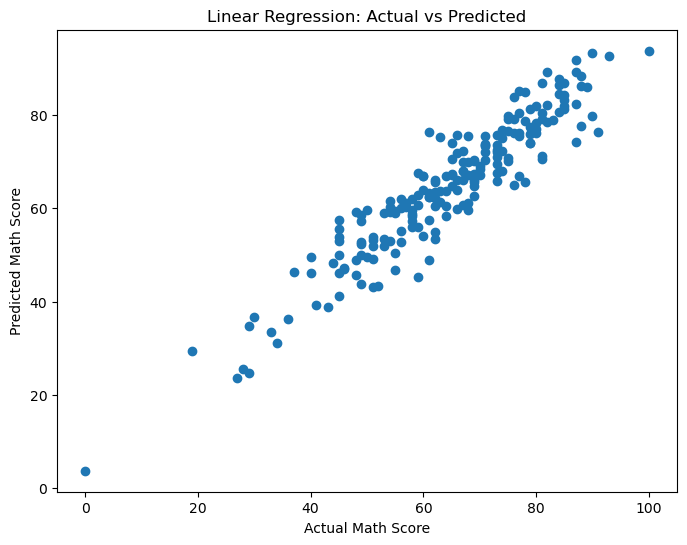

In [119]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [121]:
new_student = pd.DataFrame({
    "gender": ["male"],
    "race/ethnicity": ["group B"],
    "parental level of education": ["bachelor's degree"],
    "lunch": ["standard"],
    "test preparation course": ["completed"],
    "reading score": [70],
    "writing score": [72]
})

new_student

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,male,group B,bachelor's degree,standard,completed,70,72


In [123]:
new_student_encoded = pd.get_dummies(new_student, drop_first=True)

new_student_encoded = new_student_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

new_student_encoded

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,70,72,0,0,0,0,0,0,0,0,0,0,0,0


In [125]:
new_prediction = model.predict(new_student_encoded)

print("Predicted Math Score:", new_prediction[0])

Predicted Math Score: 57.747733403877874


In [127]:
import joblib

joblib.dump(model, "../models/linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [129]:
import os

print(os.listdir("../models"))

['linear_regression_model.pkl']
